# MC62 â€” LEAR C-shaped Dipole â€” `03_staircase_2Hz` â€” Rotating Coil Analysis

**Magnet**: MC62 (red bulk C-shaped dipole)  
**Machine**: LEAR antiproton decelerator, CERN  
**Test**: `03_staircase_2Hz` â€” streaming measurement (2026-02-16)  
**Rotation**: 2 Hz (120 rpm, â‰ˆ0.5 s per turn), 512 samples/turn  
**Current cycle**: precycles + staircase 0â†’+200â†’0â†’âˆ’200â†’0 A in 20 A steps (ramp rate 1 A/s)  
**PCBs**: Integral (R45, long coil) and Central (DQ, small coil)  
**Data format**: Binary streaming (corrected signals, 4 columns: time, abs flux, cmp flux, current)  

---
**Note on the large b2**: C-shaped dipoles have inherent left-right asymmetry (open gap
on one side, iron yoke on the other). This breaks the mid-plane symmetry that an H-dipole
would have, producing a systematic quadrupole gradient (b2) across the aperture.

**Note on precycles**: This measurement captured ~2 precycles (0â†’âˆ’200â†’+200â†’âˆ’200â†’0 A)
before the staircase, providing a view of the magnetic conditioning.

## 1. Configuration

Adjust parameters below, then **Run All**.

In [1]:
from pathlib import Path

# â”€â”€ Paths â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
MEAS_DIR = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer"
                r"\measurements\MC62_20260216_170750_staircase_2Hz\aperture1")

BIN_INTEGRAL = MEAS_DIR / "MC62_20260216_170750_staircase_2Hz_corr_sigs_Ap_1_SegIntegral.bin"
BIN_CENTRAL  = MEAS_DIR / "MC62_20260216_170750_staircase_2Hz_corr_sigs_Ap_1_SegCentral.bin"

# FFMM results for parity check
FFMM_INTEGRAL = MEAS_DIR / "MC62_20260216_170750_staircase_2Hz_results_Ap_1_Seg_Integral.txt"
FFMM_CENTRAL  = MEAS_DIR / "MC62_20260216_170750_staircase_2Hz_results_Ap_1_Seg_Central.txt"

# Kn files â€” external calibration (same PCBs as previous MC62 tests)
KN_DIR      = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer"
                   r"\measurements\2026_02_11_MC62\Kn values")
KN_INTEGRAL = KN_DIR / "Kn_R45_PCB_N1_0001_A_AC.txt"       # 30 harmonics
KN_CENTRAL  = KN_DIR / "Kn_DQ_5_18_7_250_47x50_0001_A_AC.txt"  # 15 harmonics

# â”€â”€ Magnet & coil parameters â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
MAGNET_ORDER     = 1        # dipole
R_REF            = 0.033    # reference radius [m]  (2/3 of 50 mm half-gap)
SAMPLES_PER_TURN = 512      # encoder samples per revolution (2 Hz rotation)
RPM              = 120      # rotation speed
T_PER_TURN       = 60.0 / RPM  # 0.5 s per turn

# â”€â”€ Averaging & selection â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
N_LAST_TURNS = 340          # average last 340 turns per plateau (skip first ~460 for settling)

# â”€â”€ Plateau detection â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# At 2 Hz with 1 A/s ramp, within-turn I variation during ramps is ~0.5 A.
# With threshold 1.5 ALL turns pass as plateau. Use 0.5 to separate ramps.
PLATEAU_I_RANGE_MAX = 0.5   # A (block-averaged I range threshold)
PLATEAU_MIN_LENGTH  = 50    # min turns per group (filters precycle fragments)
PLATEAU_MERGE_GAP   = 100   # merge consecutive groups at same I_nom if gap < this

# â”€â”€ Sign convention â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
FLIP_FIELD_SIGN = True      # True = flip sign of all Tesla columns

# â”€â”€ Pipeline options â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
OPTIONS        = ("dri", "rot", "cel", "fed")
PARITY_OPTIONS = ("dri", "rot", "cel", "fed", "dit")  # + dit to match FFMM C++ native
DRIFT_MODE = "legacy"
MIN_B1_T   = 1e-6           # warm dipole: lower threshold for ok_main

# â”€â”€ FFMM parity parameters â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
FFMM_R_REF = 0.33           # FFMM used R_REF=0.33 m in its results

print(f"MC62 staircase_2Hz analysis")
print(f"  Rotation:  {RPM} rpm = {60/RPM:.2f} s/turn, {SAMPLES_PER_TURN} samples/turn")
print(f"  Averaging: last {N_LAST_TURNS} turns per plateau")
print(f"  R_ref:     {R_REF*1e3:.1f} mm (analysis) / {FFMM_R_REF*1e3:.0f} mm (FFMM)")
print(f"  Plateau threshold: {PLATEAU_I_RANGE_MAX} A, min_length={PLATEAU_MIN_LENGTH}")

MC62 staircase_2Hz analysis
  Rotation:  120 rpm = 0.50 s/turn, 512 samples/turn
  Averaging: last 340 turns per plateau
  R_ref:     33.0 mm (analysis) / 330 mm (FFMM)
  Plateau threshold: 0.5 A, min_length=50


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

%matplotlib widget

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 110,
})

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import (
    compute_block_averaged_range,
    detect_plateau_turns,
    classify_current,
    find_contiguous_groups,
    process_kn_pipeline,
    build_harmonic_rows,
    diagnose_cel_fed,
)
from rotating_coil_analyzer.ingest.channel_detect import robust_range

print("Imports ready.")

## 2. Kn Calibration

External Kn files (same calibration used for all MC62 tests).  
**Note**: The measurement-embedded Kn files have only 15 harmonics (FFMM `n_multipoles=15`).
The Central embedded Kn is all-zeros (bug). We use the external files (30 harmonics integral, 15 central).

In [3]:
kn_integral = load_segment_kn_txt(str(KN_INTEGRAL))
kn_central  = load_segment_kn_txt(str(KN_CENTRAL))

for lbl, kn in [("Integral (R45)", kn_integral), ("Central (DQ)", kn_central)]:
    k1_abs = abs(kn.kn_abs[0])
    k1_cmp = abs(kn.kn_cmp[0])
    supp = k1_abs / max(k1_cmp, 1e-30)
    print(f"{lbl:20s}: {len(kn.orders):2d} harmonics, "
          f"k1_abs = {k1_abs:.6f}, suppression = {supp:.0f}x")

Integral (R45)      : 30 harmonics, k1_abs = 1.447495, suppression = 12924x
Central (DQ)        : 15 harmonics, k1_abs = 0.031959, suppression = 2302922349194870x


## 3. Load Binary Streaming Data

Binary format: 4 columns of `float64` â€” `[time_s, abs_flux, cmp_flux, I_dcct]`.  
File contains the entire measurement: precycles + staircase, ~35 800 turns.

In [4]:
Ns = SAMPLES_PER_TURN
N_COLS = 4  # time, abs_flux, cmp_flux, current

def load_binary_segment(bin_path):
    """Load a binary corrected-signals file into per-turn arrays."""
    raw = np.fromfile(str(bin_path), dtype="<f8")
    n_samples = len(raw) // N_COLS
    n_turns = n_samples // Ns
    n_keep = n_turns * Ns
    raw = raw[: n_keep * N_COLS].reshape(n_keep, N_COLS)
    t_all   = raw[:, 0].reshape(n_turns, Ns)
    ch1_all = raw[:, 1].reshape(n_turns, Ns)
    ch2_all = raw[:, 2].reshape(n_turns, Ns)
    I_all   = raw[:, 3].reshape(n_turns, Ns)
    return t_all, ch1_all, ch2_all, I_all, n_turns

print("Loading Integral binary...")
t_int, ch1_int, ch2_int, I_int, n_turns_int = load_binary_segment(BIN_INTEGRAL)
print(f"  {n_turns_int} turns, time span: {t_int[0,0]:.3f} â€“ {t_int[-1,-1]:.1f} s "
      f"({(t_int[-1,-1] - t_int[0,0])/60:.1f} min)")

print("Loading Central binary...")
t_cen, ch1_cen, ch2_cen, I_cen, n_turns_cen = load_binary_segment(BIN_CENTRAL)
print(f"  {n_turns_cen} turns")

# Channel detection from high-current turn (Integral)
I_mean_quick = I_int.mean(axis=1)
best_turn = np.argmax(np.abs(I_mean_quick))
rr1_int = robust_range(ch1_int[best_turn])
rr2_int = robust_range(ch2_int[best_turn])
SWAP_INT = rr2_int > rr1_int

flux_abs_int = ch2_int if SWAP_INT else ch1_int
flux_cmp_int = ch1_int if SWAP_INT else ch2_int
print(f"\nIntegral: col1 range={rr1_int:.3e}, col2 range={rr2_int:.3e}"
      f"  ->  {'SWAP' if SWAP_INT else 'no swap'}")

# Channel detection from high-current turn (Central)
I_mean_cen_q = I_cen.mean(axis=1)
best_turn_c = np.argmax(np.abs(I_mean_cen_q))
rr1_cen = robust_range(ch1_cen[best_turn_c])
rr2_cen = robust_range(ch2_cen[best_turn_c])
SWAP_CEN = rr2_cen > rr1_cen

flux_abs_cen = ch2_cen if SWAP_CEN else ch1_cen
flux_cmp_cen = ch1_cen if SWAP_CEN else ch2_cen
print(f"Central:  col1 range={rr1_cen:.3e}, col2 range={rr2_cen:.3e}"
      f"  ->  {'SWAP' if SWAP_CEN else 'no swap'}")

Loading Integral binary...
  35828 turns, time span: 0.001 â€“ nan s (nan min)
Loading Central binary...


  35828 turns

Integral: col1 range=7.830e-03, col2 range=1.087e-04  ->  no swap
Central:  col1 range=3.080e-04, col2 range=2.700e-07  ->  no swap


## cel/fed Safety Diagnostic

Run `diagnose_cel_fed()` to check whether the centre-location +
feeddown correction is safe for this data.

In [ ]:
# Use a sample of turns for the diagnostic (e.g., first 100 turns)
_n_diag = min(100, flux_abs_int.shape[0])
diag = diagnose_cel_fed(
    flux_abs_int[:_n_diag], flux_cmp_int[:_n_diag],
    t_int[:_n_diag], I_int[:_n_diag],
    kn=kn_integral, r_ref=R_REF, magnet_order=MAGNET_ORDER,
)
print(f"cel/fed diagnostic: {diag.recommendation}")
print(f"  {diag.reason}")
_Bd = np.max(np.abs(diag.B_main_with_fed - diag.B_main_without_fed))
print(f"  B_main max |diff|: {_Bd:.4e} T")
del _n_diag, _Bd

## 4. Current Profile & Plateau Detection

Identify precycle turns, ramp turns, and staircase plateau turns using
the standard three-rule plateau detection.

Total turns: 35828
Plateau turns: 33453 / 35828
I range: -200.1 .. 200.1 A


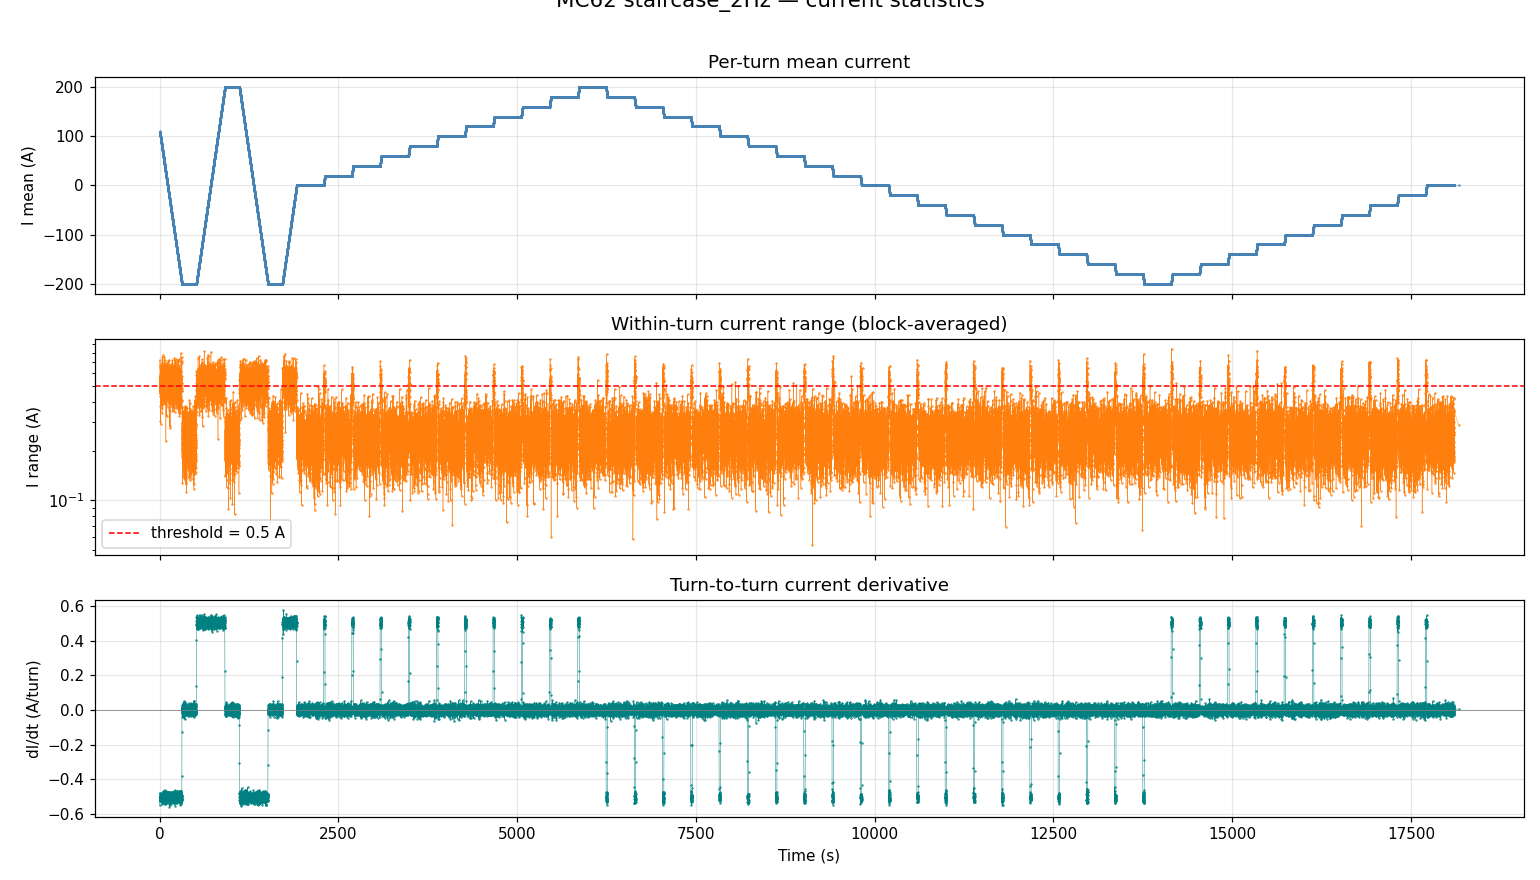

In [5]:
# Per-turn statistics
I_mean  = I_int.mean(axis=1)
t_mean  = t_int.mean(axis=1)

# Block-averaged current range
N_BLOCKS = 10
I_range, I_blocks = compute_block_averaged_range(I_int, Ns, N_BLOCKS)

# Plateau detection
plateau_info = detect_plateau_turns(I_blocks, I_mean, I_range, PLATEAU_I_RANGE_MAX)
is_plateau = plateau_info["is_plateau"]

print(f"Total turns: {n_turns_int}")
print(f"Plateau turns: {is_plateau.sum()} / {n_turns_int}")
print(f"I range: {I_mean.min():.1f} .. {I_mean.max():.1f} A")

# Turn-to-turn dI/dt
dI_dt = np.gradient(I_mean)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
ax.plot(t_mean, I_mean, ".-", markersize=1, linewidth=0.3, color="steelblue")
ax.set_ylabel("I mean (A)")
ax.set_title("Per-turn mean current")

ax = axes[1]
ax.semilogy(t_mean, I_range, ".-", markersize=1, linewidth=0.3, color="tab:orange")
ax.axhline(PLATEAU_I_RANGE_MAX, color="red", ls="--", lw=1,
           label=f"threshold = {PLATEAU_I_RANGE_MAX} A")
ax.set_ylabel("I range (A)")
ax.set_title("Within-turn current range (block-averaged)")
ax.legend()

ax = axes[2]
ax.plot(t_mean, dI_dt, ".-", markersize=1, linewidth=0.3, color="teal")
ax.axhline(0, color="grey", lw=0.5)
ax.set_ylabel("dI/dt (A/turn)")
ax.set_xlabel("Time (s)")
ax.set_title("Turn-to-turn current derivative")

fig.suptitle("MC62 staircase_2Hz â€” current statistics", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Identify Precycles vs Staircase

Cluster contiguous plateau groups and identify the staircase region.
The precycles have long ramps with brief pauses at Â±200 A and 0 A;
the staircase has systematic 20 A steps with ~800 turns per plateau.

In [6]:
# Find contiguous plateau groups (min_length filters tiny precycle fragments)
plateau_groups_raw = find_contiguous_groups(is_plateau, min_length=PLATEAU_MIN_LENGTH)

# Build group info with I_nom
group_info = []
for gi, (gs, ge) in enumerate(plateau_groups_raw):
    I_grp = I_mean[gs:ge+1]
    t_grp = t_mean[gs:ge+1]
    I_nom = round(I_grp.mean() / 20) * 20
    group_info.append({
        "group": gi,
        "start": gs,
        "end": ge,
        "n_turns": ge - gs + 1,
        "I_mean": I_grp.mean(),
        "I_nom": I_nom,
        "I_std": I_grp.std(),
        "t_start": t_grp[0],
        "t_end": t_grp[-1],
    })

# Merge consecutive groups at the same I_nom with small gap (ramp splits)
merged = [group_info[0].copy()]
for g in group_info[1:]:
    prev = merged[-1]
    gap = g["start"] - prev["end"]
    if g["I_nom"] == prev["I_nom"] and gap < PLATEAU_MERGE_GAP:
        # Extend the previous group to cover both
        prev["end"] = g["end"]
        prev["n_turns"] = prev["end"] - prev["start"] + 1
        I_slice = I_mean[prev["start"]:prev["end"]+1]
        prev["I_mean"] = I_slice.mean()
        prev["I_std"] = I_slice.std()
        prev["t_end"] = t_mean[prev["end"]]
    else:
        merged.append(g.copy())

# Re-index
for i, g in enumerate(merged):
    g["group"] = i

df_groups = pd.DataFrame(merged)
print(f"Found {len(df_groups)} plateau groups (after merge)")

# Classify: staircase starts at first 0 A plateau with >= 500 turns
staircase_start_group = None
for i, row in df_groups.iterrows():
    if abs(row["I_nom"]) < 2.0 and row["n_turns"] >= 500:
        staircase_start_group = i
        break

if staircase_start_group is not None:
    staircase_start_turn = int(df_groups.loc[staircase_start_group, "start"])
    n_precycle_groups = staircase_start_group
    n_staircase_groups = len(df_groups) - staircase_start_group
    print(f"\nPrecycle region: groups 0â€“{staircase_start_group-1} "
          f"(turns 0â€“{staircase_start_turn-1})")
    print(f"Staircase region: groups {staircase_start_group}â€“{len(df_groups)-1} "
          f"(turns {staircase_start_turn}â€“{n_turns_int-1}), "
          f"{n_staircase_groups} plateaus")
else:
    staircase_start_turn = 0
    staircase_start_group = 0
    print("WARNING: could not identify staircase start, treating all data as staircase")

# Show group summary
print(f"\n{'Grp':>4s} {'Start':>7s} {'End':>7s} {'N':>6s} {'I_nom':>8s} {'Region':>10s}")
print("-" * 50)
for i, row in df_groups.iterrows():
    region = "precycle" if i < staircase_start_group else "staircase"
    print(f"{i:4d} {row['start']:7.0f} {row['end']:7.0f} {row['n_turns']:6.0f} "
          f"{row['I_nom']:+8.0f} {region:>10s}")

Found 44 plateau groups (after merge)

Precycle region: groups 0â€“2 (turns 0â€“3785)
Staircase region: groups 3â€“43 (turns 3786â€“35827), 41 plateaus

 Grp   Start     End      N    I_nom     Region
--------------------------------------------------
   0     614    1012    399     -200   precycle
   1    1804    2203    400     +200   precycle
   2    2994    3394    401     -200   precycle
   3    3786    4535    750       +0  staircase
   4    4573    5298    726      +20  staircase
   5    5353    6097    745      +40  staircase
   6    6131    6879    749      +60  staircase
   7    6923    7660    738      +80  staircase
   8    7700    8444    745     +100  staircase
   9    8478    9225    748     +120  staircase
  10    9262   10005    744     +140  staircase
  11   10043   10789    747     +160  staircase
  12   10825   11570    746     +180  staircase
  13   11608   12350    743     +200  staircase
  14   12390   13131    742     +180  staircase
  15   13171   13914    744 

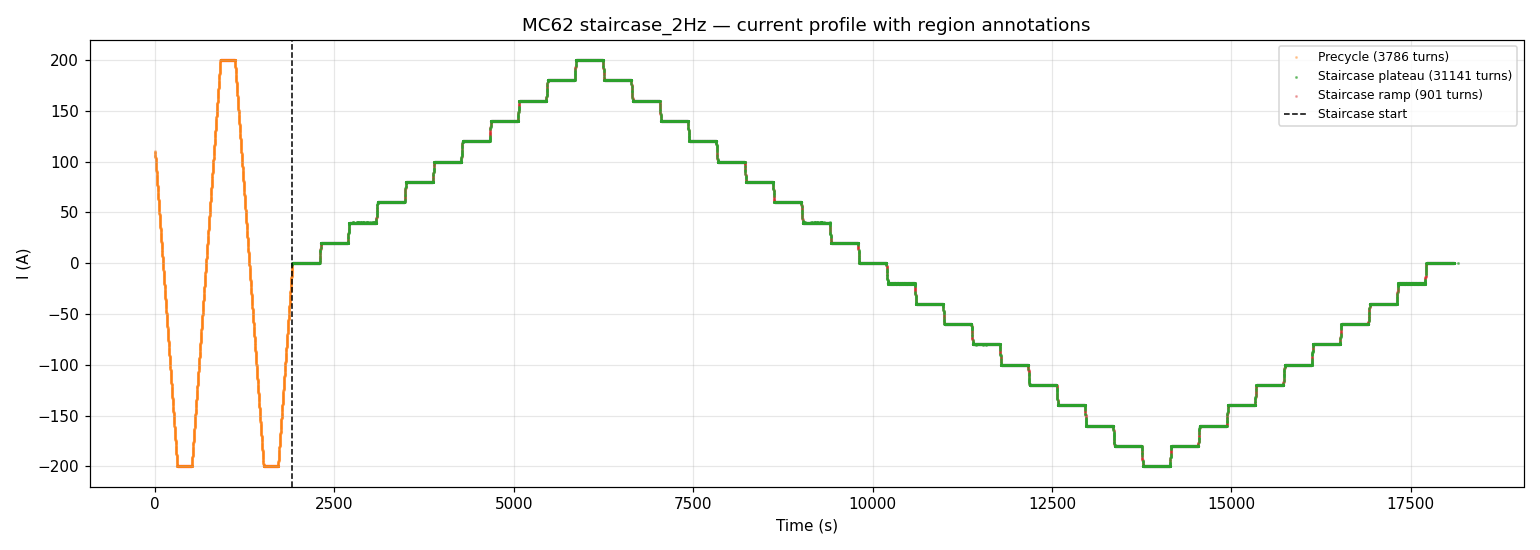

In [7]:
# Annotated current profile
fig, ax = plt.subplots(figsize=(14, 5))

# Background: all turns
ax.plot(t_mean, I_mean, linewidth=0.3, color="lightgrey", zorder=0)

# Precycle turns
pre_mask = np.arange(n_turns_int) < staircase_start_turn
if pre_mask.any():
    ax.scatter(t_mean[pre_mask], I_mean[pre_mask], s=1, color="tab:orange",
              alpha=0.3, label=f"Precycle ({pre_mask.sum()} turns)", zorder=1)

# Staircase plateau turns
stair_plateau = is_plateau & (~pre_mask)
ax.scatter(t_mean[stair_plateau], I_mean[stair_plateau], s=1, color="tab:green",
          alpha=0.5, label=f"Staircase plateau ({stair_plateau.sum()} turns)", zorder=2)

# Staircase ramp turns
stair_ramp = (~is_plateau) & (~pre_mask)
ax.scatter(t_mean[stair_ramp], I_mean[stair_ramp], s=1, color="tab:red",
          alpha=0.3, label=f"Staircase ramp ({stair_ramp.sum()} turns)", zorder=1)

ax.axvline(t_mean[staircase_start_turn], color="black", ls="--", lw=1,
           label="Staircase start")
ax.set_xlabel("Time (s)")
ax.set_ylabel("I (A)")
ax.set_title("MC62 staircase_2Hz â€” current profile with region annotations")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 6. Assign Staircase Runs

Map each staircase plateau group to a run ID, nominal current, and branch direction.
This mimics the run-based structure of the previous MC62 tests.

In [8]:
# Build run-level metadata from staircase plateau groups
staircase_groups = df_groups[df_groups.index >= staircase_start_group].copy()
staircase_groups = staircase_groups.reset_index(drop=True)
staircase_groups["run_id"] = range(len(staircase_groups))

# Round nominal current to nearest 20 A
staircase_groups["I_nom"] = (staircase_groups["I_mean"] / 20).round() * 20

# Branch direction
branches = ["ascending"]
for i in range(1, len(staircase_groups)):
    if staircase_groups.iloc[i]["I_nom"] > staircase_groups.iloc[i-1]["I_nom"]:
        branches.append("ascending")
    elif staircase_groups.iloc[i]["I_nom"] < staircase_groups.iloc[i-1]["I_nom"]:
        branches.append("descending")
    else:
        branches.append(branches[-1])
staircase_groups["branch"] = branches

# Build a per-turn lookup: turn_idx -> (run_id, I_nom, branch, turn_in_run)
turn_run_map = {}
for _, row in staircase_groups.iterrows():
    start = int(row["start"])
    end = int(row["end"])
    for t in range(start, end + 1):
        turn_run_map[t] = {
            "run_id": int(row["run_id"]),
            "I_nom": row["I_nom"],
            "branch": row["branch"],
            "turn_in_run": t - start,
        }

print(f"Staircase: {len(staircase_groups)} plateaus")
print(f"\n{'Run':>4s} {'I_nom':>8s} {'Branch':>10s} {'Turns':>6s} {'Start':>7s} {'End':>7s}")
print("-" * 50)
for _, r in staircase_groups.iterrows():
    print(f"{r['run_id']:4.0f} {r['I_nom']:+8.0f} {r['branch']:>10s} "
          f"{r['n_turns']:6.0f} {r['start']:7.0f} {r['end']:7.0f}")

Staircase: 41 plateaus

 Run    I_nom     Branch  Turns   Start     End
--------------------------------------------------
   0       +0  ascending    750    3786    4535
   1      +20  ascending    726    4573    5298
   2      +40  ascending    745    5353    6097
   3      +60  ascending    749    6131    6879
   4      +80  ascending    738    6923    7660
   5     +100  ascending    745    7700    8444
   6     +120  ascending    748    8478    9225
   7     +140  ascending    744    9262   10005
   8     +160  ascending    747   10043   10789
   9     +180  ascending    746   10825   11570
  10     +200  ascending    743   11608   12350
  11     +180 descending    742   12390   13131
  12     +160 descending    744   13171   13914
  13     +140 descending    746   13950   14695
  14     +120 descending    745   14734   15478
  15     +100 descending    742   15517   16258
  16      +80 descending    749   16298   17046
  17      +60 descending    746   17080   17825
  18      +40

## 7. Process All Staircase Plateau Turns Through Kn Pipeline

Process only the staircase plateau turns (skip precycle and ramp turns).

In [9]:
def process_streaming_segment(flux_abs, flux_cmp, t_all, I_all,
                               kn, label, merge_mode="abs_upto_m_cmp_above"):
    """Process staircase plateau turns from streaming data."""
    # Collect plateau turn indices
    plateau_indices = sorted(turn_run_map.keys())
    idx = np.array(plateau_indices)
    print(f"[{label}] Processing {len(idx)} plateau turns (merge: {merge_mode})...")

    result, C_merged, C_units, ok_main = process_kn_pipeline(
        flux_abs_turns=flux_abs[idx],
        flux_cmp_turns=flux_cmp[idx],
        t_turns=t_all[idx],
        I_turns=I_all[idx],
        kn=kn,
        r_ref=R_REF,
        magnet_order=MAGNET_ORDER,
        options=OPTIONS,
        drift_mode=DRIFT_MODE,
        min_b1_T=MIN_B1_T,
        merge_mode=merge_mode,
    )

    extra = [turn_run_map[t] for t in plateau_indices]
    rows = build_harmonic_rows(result, C_merged, C_units, ok_main,
                               MAGNET_ORDER, extra)

    df = pd.DataFrame(rows)
    n_ok = int(df["ok_main"].sum())
    print(f"  {len(df)} turns processed, {n_ok} ok")
    return df

df_int = process_streaming_segment(flux_abs_int, flux_cmp_int, t_int, I_int,
                                    kn_integral, "Integral")
df_cen = process_streaming_segment(flux_abs_cen, flux_cmp_cen, t_cen, I_cen,
                                    kn_central, "Central", merge_mode="abs_all")

# Sign convention
if FLIP_FIELD_SIGN:
    for _df in [df_int, df_cen]:
        abs_cols = [c for c in _df.columns if c.endswith("_T")]
        _df[abs_cols] *= -1
    print("\n[Sign flip applied to Tesla columns]")

print(f"\nIntegral: {len(df_int)} rows  |  Central: {len(df_cen)} rows")

[Integral] Processing 30466 plateau turns (merge: abs_upto_m_cmp_above)...


  30466 turns processed, 30465 ok
[Central] Processing 30466 plateau turns (merge: abs_all)...


  30466 turns processed, 30465 ok

[Sign flip applied to Tesla columns]

Integral: 30466 rows  |  Central: 30466 rows


## 8. Plateau Quality & Averaging

Select the last N turns per plateau to let eddy currents settle.

In [10]:
from rotating_coil_analyzer.analysis.utility_functions import plateau_summary, plot_hysteresis

summ_int = plateau_summary(df_int, N_LAST_TURNS)
summ_cen = plateau_summary(df_cen, N_LAST_TURNS)

cols_show = ["run_id", "I_nom", "branch", "n_ok",
             "B1_mean", "B1_std", "quality"]
print("=== Integral PCB (R45) ===")
print(summ_int[cols_show].to_string(index=False, float_format="%.6f"))
print(f"\n=== Central PCB (DQ) ===")
print(summ_cen[cols_show].to_string(index=False, float_format="%.6f"))

=== Integral PCB (R45) ===
 run_id       I_nom     branch  n_ok   B1_mean   B1_std quality
      0    0.000000  ascending   340 -0.000351 0.000013    good
      1   20.000000  ascending   340  0.024575 0.000006    good
      2   40.000000  ascending   340  0.049536 0.000009    good
      3   60.000000  ascending   340  0.074485 0.000015    good
      4   80.000000  ascending   340  0.099397 0.000016    good
      5  100.000000  ascending   340  0.124241 0.000052    good
      6  120.000000  ascending   340  0.148910 0.000040    good
      7  140.000000  ascending   340  0.172417 0.000023    good
      8  160.000000  ascending   340  0.191416 0.000040    good
      9  180.000000  ascending   340  0.206238 0.000032    good
     10  200.000000  ascending   340  0.218517 0.000033    good
     11  180.000000 descending   340  0.206943 0.000028    good
     12  160.000000 descending   340  0.192401 0.000027    good
     13  140.000000 descending   340  0.173524 0.000026    good
     14  120.

## 9. B1 (Main Dipole Field) vs Current â€” Hysteresis

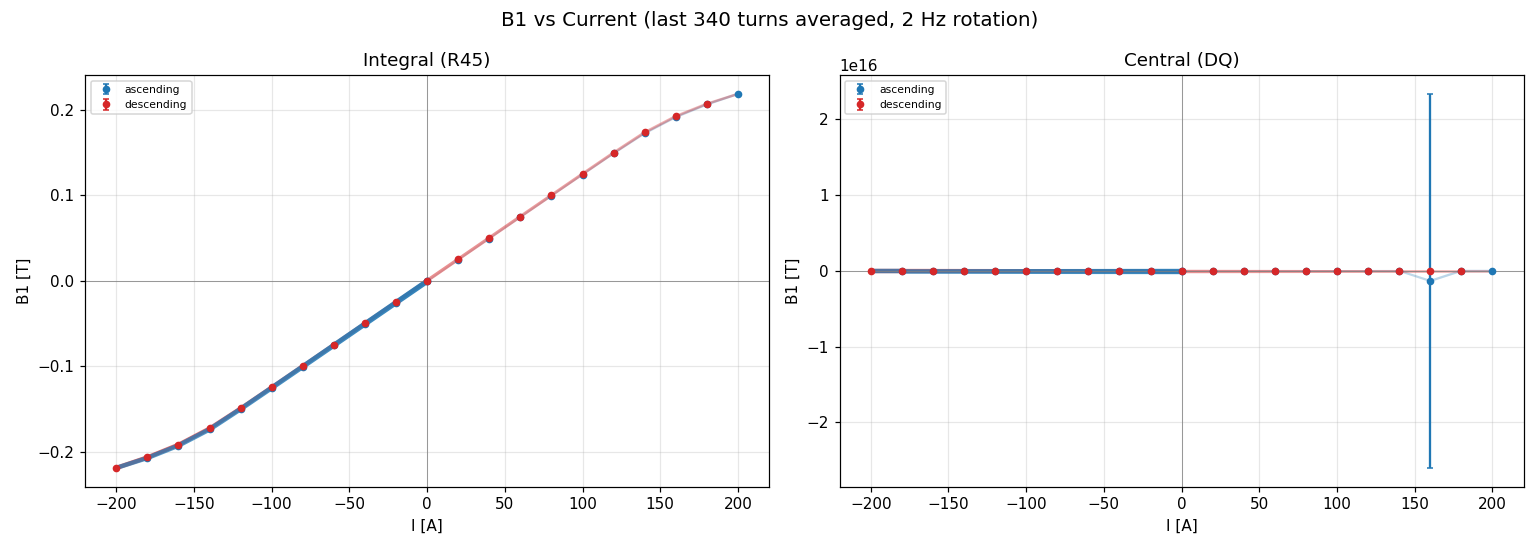

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    plot_hysteresis(ax, summ, "I_nom", "B1_mean", "B1_std")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("B1 [T]")
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)

fig.suptitle(f"B1 vs Current (last {N_LAST_TURNS} turns averaged, 2 Hz rotation)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 10. b2 (Quadrupole) vs Current

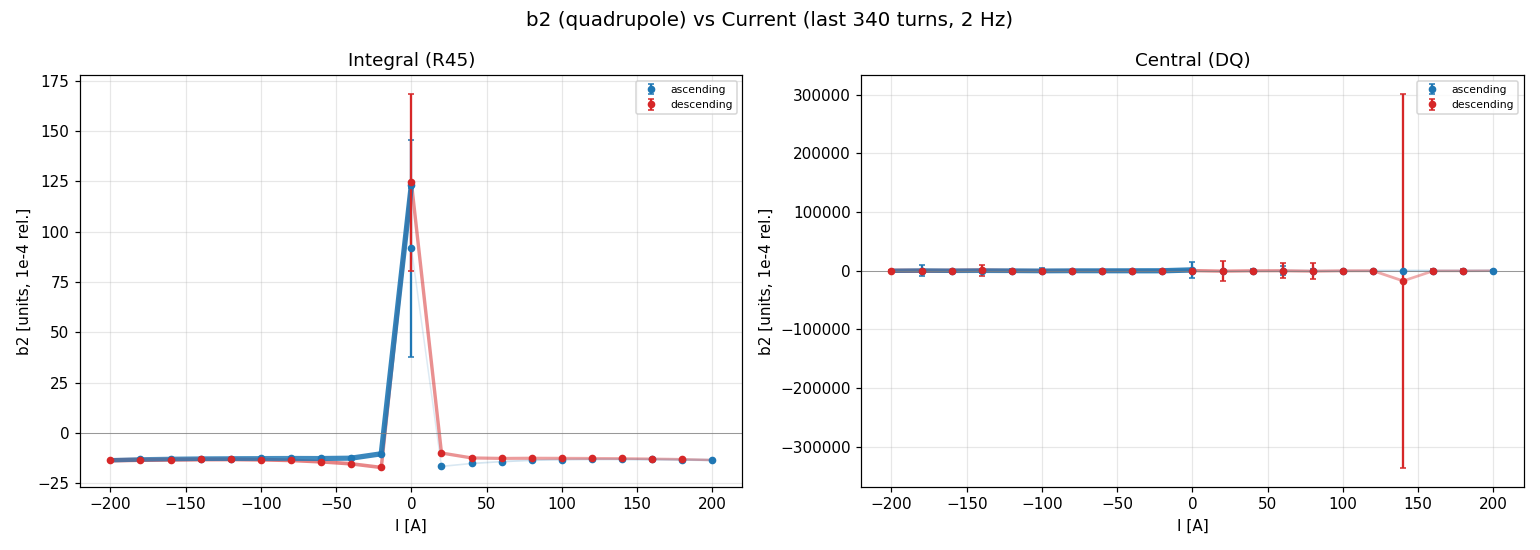

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    plot_hysteresis(ax, summ, "I_nom", "b2_units_mean", "b2_units_std")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("b2 [units, 1e-4 rel.]")
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.axhline(0, color="gray", lw=0.5)

fig.suptitle(f"b2 (quadrupole) vs Current (last {N_LAST_TURNS} turns, 2 Hz)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 11. b3 (Sextupole) vs Current

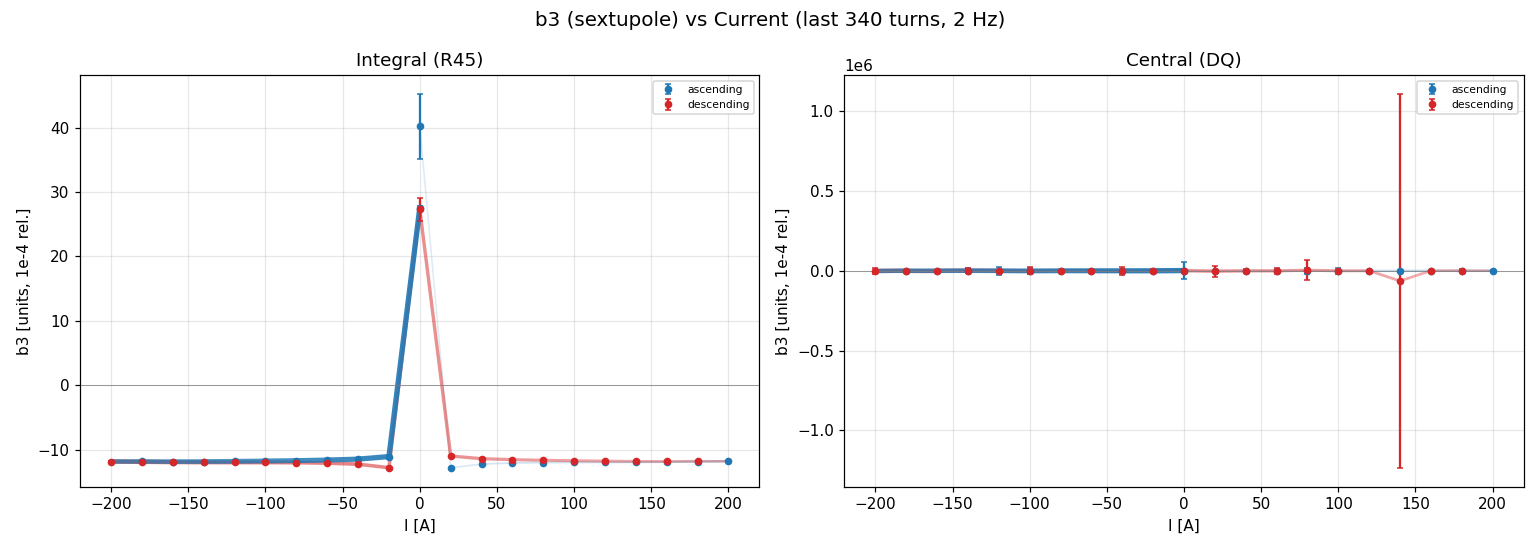

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    plot_hysteresis(ax, summ, "I_nom", "b3_units_mean", "b3_units_std")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("b3 [units, 1e-4 rel.]")
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.axhline(0, color="gray", lw=0.5)

fig.suptitle(f"b3 (sextupole) vs Current (last {N_LAST_TURNS} turns, 2 Hz)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 12. Transfer Function B1/I vs I

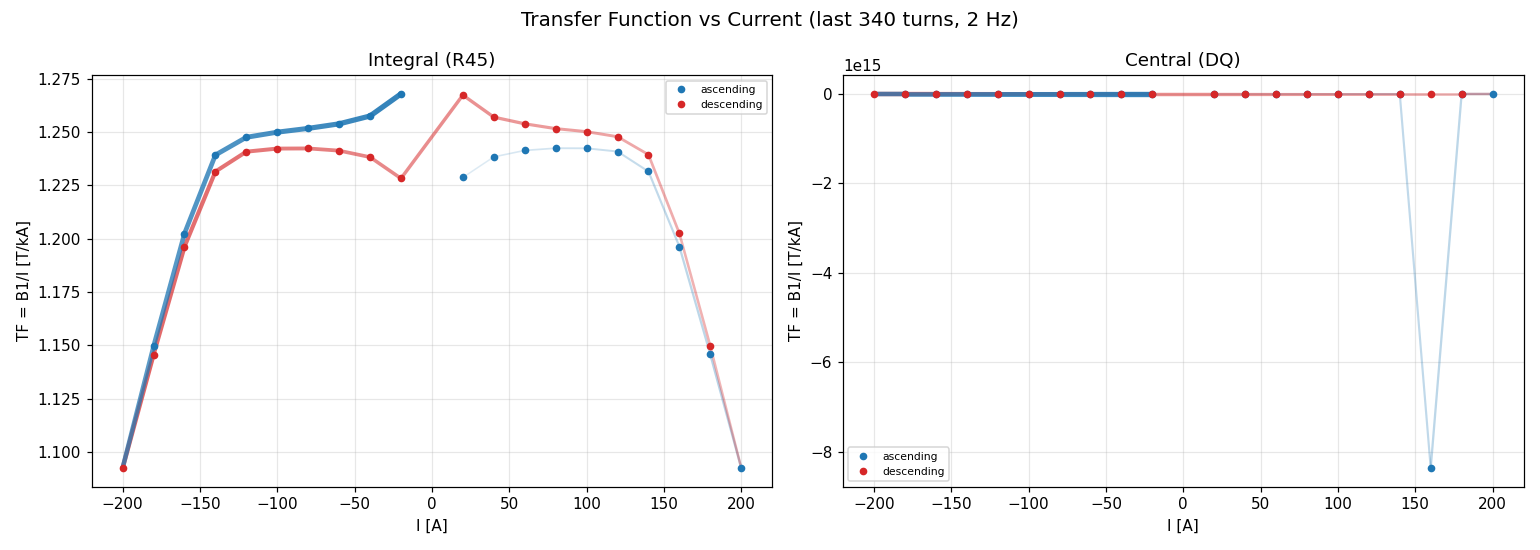

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    plot_hysteresis(ax, summ, "I_nom", "TF")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("TF = B1/I [T/kA]")
    ax.set_title(label)
    ax.legend(fontsize=7)

fig.suptitle(f"Transfer Function vs Current (last {N_LAST_TURNS} turns, 2 Hz)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 13. Multipole Spectrum at Peak Current

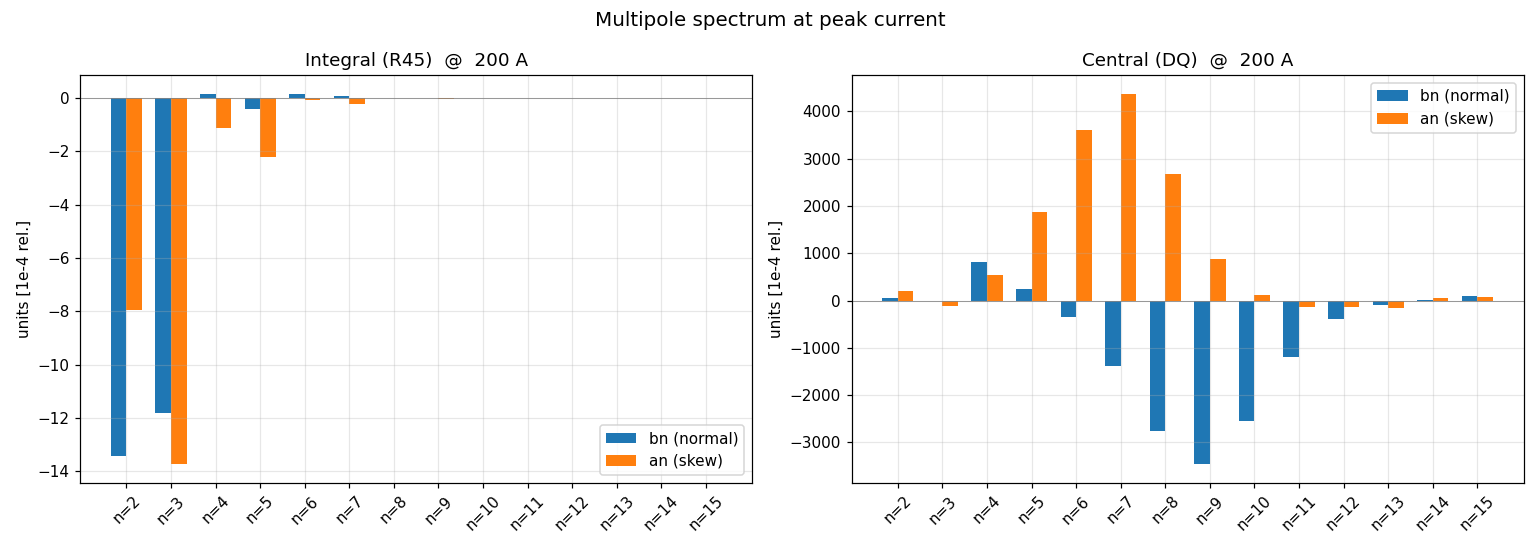

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    good = summ[summ["quality"] == "good"]
    if good.empty:
        ax.set_title(f"{label}: no valid data")
        continue
    peak = good.loc[good["I_nom"].abs().idxmax()]

    orders, bn, an = [], [], []
    for n in range(2, 16):
        bc = f"b{n}_units_mean"
        ac = f"a{n}_units_mean"
        if bc in summ.columns and pd.notna(peak.get(bc)):
            orders.append(n)
            bn.append(peak[bc])
            an.append(peak.get(ac, 0.0) if pd.notna(peak.get(ac)) else 0.0)

    if orders:
        x = np.arange(len(orders))
        w = 0.35
        ax.bar(x - w/2, bn, w, label="bn (normal)", color="tab:blue")
        ax.bar(x + w/2, an, w, label="an (skew)", color="tab:orange")
        ax.set_xticks(x)
        ax.set_xticklabels([f"n={o}" for o in orders], rotation=45)
        ax.set_ylabel("units [1e-4 rel.]")
        ax.set_title(f"{label}  @  {peak['I_nom']:.0f} A")
        ax.legend()
        ax.axhline(0, color="gray", lw=0.5)

fig.suptitle("Multipole spectrum at peak current", fontsize=13)
fig.tight_layout()
plt.show()

## 14. Summary Table

In [16]:
def format_summary(summ, label):
    print(f"\n{'=' * 90}")
    print(f"  {label}")
    print(f"  R_ref = {R_REF*1e3:.1f} mm  |  "
          f"last {N_LAST_TURNS} turns averaged  |  2 Hz rotation")
    print(f"{'=' * 90}")
    hdr = (f"{'Run':>4s} {'I [A]':>8s} {'Branch':>10s} "
           f"{'B1 [T]':>12s} {'b2 [units]':>12s} "
           f"{'b3 [units]':>12s} {'TF [T/kA]':>10s} {'Qual':>5s}")
    print(hdr)
    print("-" * 90)
    for _, r in summ.iterrows():
        b1 = f"{r['B1_mean']:.6f}" if pd.notna(r['B1_mean']) else "---"
        b2 = (f"{r.get('b2_units_mean', np.nan):.2f}"
              if pd.notna(r.get('b2_units_mean')) else "---")
        b3 = (f"{r.get('b3_units_mean', np.nan):.2f}"
              if pd.notna(r.get('b3_units_mean')) else "---")
        tf = f"{r['TF']:.4f}" if pd.notna(r['TF']) else "---"
        print(f"{r['run_id']:4.0f} {r['I_nom']:+8.1f} "
              f"{r['branch']:>10s} {b1:>12s} {b2:>12s} "
              f"{b3:>12s} {tf:>10s} {r['quality']:>5s}")

format_summary(summ_int, "Integral PCB (R45)")
format_summary(summ_cen, "Central PCB (DQ)")


  Integral PCB (R45)
  R_ref = 33.0 mm  |  last 340 turns averaged  |  2 Hz rotation
 Run    I [A]     Branch       B1 [T]   b2 [units]   b3 [units]  TF [T/kA]  Qual
------------------------------------------------------------------------------------------
   0     +0.0  ascending    -0.000351        91.73        40.23        ---  good
   1    +20.0  ascending     0.024575       -16.61       -12.81     1.2287  good
   2    +40.0  ascending     0.049536       -15.16       -12.25     1.2384  good
   3    +60.0  ascending     0.074485       -14.22       -12.07     1.2414  good
   4    +80.0  ascending     0.099397       -13.55       -12.00     1.2425  good
   5   +100.0  ascending     0.124241       -13.20       -11.97     1.2424  good
   6   +120.0  ascending     0.148910       -13.04       -11.96     1.2409  good
   7   +140.0  ascending     0.172417       -13.03       -11.94     1.2315  good
   8   +160.0  ascending     0.191416       -13.13       -11.91     1.1964  good
   9   +180.0

---
## 15. Golden Standard Parity Check â€” Our Pipeline vs FFMM (C++)

Compare our per-turn results against the FFMM C++ analyzer output.
Both pipelines process the same raw binary data.

**FFMM convention**: `R_REF = 0.33 m`, 15 harmonics.  
**Our convention**: `R_REF = 0.033 m`, 30 harmonics (integral).  

For parity, we re-run our pipeline with `R_REF = 0.33 m` on **all** turns
(matching FFMM which processes every turn, not just plateaus) and compare
`B_main` (T, R_REF-independent) and harmonics at the same reference radius.

**Note**: FFMM Central results are all NaN (embedded Central Kn was all-zeros).
Parity check is Integral only.

In [17]:
# Load FFMM per-turn results (Integral only â€” Central is all NaN)
ffmm = pd.read_csv(str(FFMM_INTEGRAL), sep="\t", skipinitialspace=True)
ffmm.columns = [c.strip() for c in ffmm.columns]
n_ffmm = len(ffmm)
print(f"FFMM Integral results: {n_ffmm} turns")
print(f"  Time span: {ffmm['Time(s)'].iloc[0]:.1f} â€“ {ffmm['Time(s)'].iloc[-1]:.1f} s")
print(f"  Rref = {ffmm['Rref(m)'].iloc[0]} m, Lcoil = {ffmm['Lcoil(m)'].iloc[0]} m")
print(f"  Columns: {list(ffmm.columns[:15])} ...")

# Verify Central is NaN
ffmm_cen_check = pd.read_csv(str(FFMM_CENTRAL), sep="\t", nrows=5)
print(f"\nFFMM Central B_main sample: {ffmm_cen_check['B_main(T)'].tolist()}")
print("  -> All NaN (Central Kn was all-zeros in measurement). Parity = Integral only.")

FFMM Integral results: 35826 turns
  Time span: 0.3 â€“ 18105.4 s
  Rref = 0.33 m, Lcoil = 1.2 m
  Columns: ['Time(s)', 'Duration(s)', 'Options', 'Rref(m)', 'Lcoil(m)', 'I(A)', 'Ramprate(A/s)', 'dx(mm)', 'dy(mm)', 'phi(rad)', 'B_main(T)', 'A_main(T)', 'B_main_TF(T/kA)', 'A_main_TF(T/kA)', 'B1(T)'] ...

FFMM Central B_main sample: [nan, nan, nan, nan, nan]
  -> All NaN (Central Kn was all-zeros in measurement). Parity = Integral only.


In [18]:
# Re-run our pipeline on ALL turns with R_REF=0.33 for parity comparison
# Use 15-harmonic Kn (matching FFMM's n_multipoles=15) from measurement file
KN_MEAS_INTEGRAL = MEAS_DIR / "MC62_20260216_170750_staircase_2Hz_Kn_values_Ap_1_Seg_Integral.txt"
kn_parity = load_segment_kn_txt(str(KN_MEAS_INTEGRAL))
print(f"Parity Kn: {len(kn_parity.orders)} harmonics (from measurement file)")

# Process in chunks to avoid memory issues (35828 turns x 512 samples)
n_all = min(n_turns_int, n_ffmm)  # match FFMM turn count
print(f"Processing {n_all} turns with R_REF={FFMM_R_REF} m for parity...")
print(f"Parity options: {PARITY_OPTIONS}  (dit_signed=True to match C++ native)")

CHUNK = 5000
all_parity_rows = []
for c_start in range(0, n_all, CHUNK):
    c_end = min(c_start + CHUNK, n_all)
    idx = np.arange(c_start, c_end)

    result_p, C_merged_p, C_units_p, ok_main_p = process_kn_pipeline(
        flux_abs_turns=flux_abs_int[idx],
        flux_cmp_turns=flux_cmp_int[idx],
        t_turns=t_int[idx],
        I_turns=I_int[idx],
        kn=kn_parity,
        r_ref=FFMM_R_REF,
        magnet_order=MAGNET_ORDER,
        options=PARITY_OPTIONS,
        drift_mode=DRIFT_MODE,
        min_b1_T=MIN_B1_T,
        merge_mode="abs_upto_m_cmp_above",
        dit_signed=True,
    )

    extra = [{"global_turn": int(t)} for t in idx]
    rows = build_harmonic_rows(result_p, C_merged_p, C_units_p, ok_main_p,
                               MAGNET_ORDER, extra)
    all_parity_rows.extend(rows)
    print(f"  chunk {c_start}â€“{c_end}: done")

df_parity = pd.DataFrame(all_parity_rows)
print(f"\nParity DataFrame: {len(df_parity)} rows")

Parity Kn: 15 harmonics (from measurement file)
Processing 35826 turns with R_REF=0.33 m for parity...
Parity options: ('dri', 'rot', 'cel', 'fed', 'dit')  (dit_signed=True to match C++ native)


  chunk 0â€“5000: done


  chunk 5000â€“10000: done


  chunk 10000â€“15000: done


  chunk 15000â€“20000: done


  chunk 20000â€“25000: done


  chunk 25000â€“30000: done


  chunk 30000â€“35000: done
  chunk 35000â€“35826: done

Parity DataFrame: 35826 rows


  PARITY CHECK: B_main (T)  â€”  Our pipeline vs FFMM C++
  Turns compared: 35826
  Max |diff|:     1.811537e-13 T
  Mean |diff|:    6.242615e-17 T
  RMS diff:       1.417347e-15 T
  Median |diff|:  2.775558e-17 T

  Relative (|B_main| > 0.01 T, 33405 turns):
  Max  |rel diff|: 7.124592e-12
  Mean |rel diff|: 1.282774e-15
  Median:          2.682762e-16


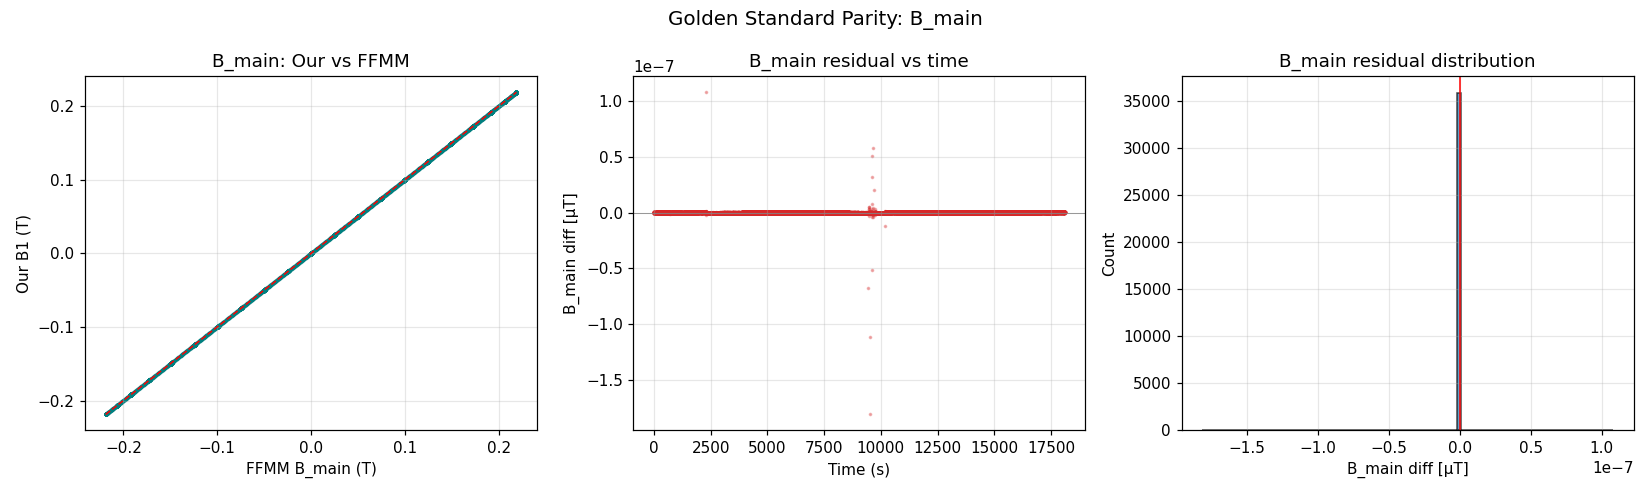

In [19]:
# Compare B_main (our B1_T vs FFMM B_main(T))
our_B1 = df_parity["B1_T"].values[:n_ffmm]
ffmm_B1 = ffmm["B_main(T)"].values

diff_B1 = our_B1 - ffmm_B1
abs_diff = np.abs(diff_B1)

print("=" * 70)
print("  PARITY CHECK: B_main (T)  â€”  Our pipeline vs FFMM C++")
print("=" * 70)
print(f"  Turns compared: {n_ffmm}")
print(f"  Max |diff|:     {abs_diff.max():.6e} T")
print(f"  Mean |diff|:    {abs_diff.mean():.6e} T")
print(f"  RMS diff:       {np.sqrt(np.mean(diff_B1**2)):.6e} T")
print(f"  Median |diff|:  {np.median(abs_diff):.6e} T")

# Relative difference where |B_main| > 0.01 T
mask_ok = np.abs(ffmm_B1) > 0.01
rel_diff = np.abs(diff_B1[mask_ok] / ffmm_B1[mask_ok])
print(f"\n  Relative (|B_main| > 0.01 T, {mask_ok.sum()} turns):")
print(f"  Max  |rel diff|: {rel_diff.max():.6e}")
print(f"  Mean |rel diff|: {rel_diff.mean():.6e}")
print(f"  Median:          {np.median(rel_diff):.6e}")

# Scatter plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
ax.scatter(ffmm_B1, our_B1, s=2, alpha=0.3, c="teal")
lims = [ffmm_B1.min(), ffmm_B1.max()]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("FFMM B_main (T)")
ax.set_ylabel("Our B1 (T)")
ax.set_title("B_main: Our vs FFMM")

ax = axes[1]
ax.scatter(df_parity["time_s"].values[:n_ffmm], diff_B1 * 1e6,
           s=2, alpha=0.3, c="tab:red")
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("B_main diff [ÂµT]")
ax.set_title("B_main residual vs time")

ax = axes[2]
ax.hist(diff_B1 * 1e6, bins=100, color="tab:blue", alpha=0.7, edgecolor="black")
ax.axvline(0, color="red", lw=1)
ax.set_xlabel("B_main diff [ÂµT]")
ax.set_ylabel("Count")
ax.set_title("B_main residual distribution")

fig.suptitle("Golden Standard Parity: B_main", fontsize=13)
fig.tight_layout()
plt.show()

In [20]:
# Compare harmonics (b2, b3) at FFMM's R_REF=0.33
print("=" * 70)
print("  PARITY CHECK: Harmonics  â€”  Our vs FFMM (Rref = 0.33 m)")
print("=" * 70)

# Only compare where B_main is meaningful (|I| > 10 A and ok_main)
mask_harm = (np.abs(ffmm["I(A)"].values) > 10) & df_parity["ok_main"].values[:n_ffmm]
n_harm = mask_harm.sum()
print(f"  Turns for harmonic comparison: {n_harm} (|I| > 10 A and ok_main)")

for n_ord in range(2, 11):
    bn_col = f"b{n_ord}_units"
    an_col = f"a{n_ord}_units"
    ffmm_bn_col = f"b{n_ord}(Units)"
    ffmm_an_col = f"a{n_ord}(Units)"

    if bn_col not in df_parity.columns or ffmm_bn_col not in ffmm.columns:
        continue

    our_bn = df_parity[bn_col].values[:n_ffmm][mask_harm]
    ffmm_bn = ffmm[ffmm_bn_col].values[mask_harm]
    diff_bn = our_bn - ffmm_bn
    rms_bn = np.sqrt(np.mean(diff_bn**2))

    our_an = df_parity[an_col].values[:n_ffmm][mask_harm]
    ffmm_an = ffmm[ffmm_an_col].values[mask_harm]
    diff_an = our_an - ffmm_an
    rms_an = np.sqrt(np.mean(diff_an**2))

    print(f"  b{n_ord}: RMS diff = {rms_bn:.4f} units, "
          f"max |diff| = {np.abs(diff_bn).max():.4f} | "
          f"a{n_ord}: RMS = {rms_an:.4f}, max = {np.abs(diff_an).max():.4f}")

  PARITY CHECK: Harmonics  â€”  Our vs FFMM (Rref = 0.33 m)
  Turns for harmonic comparison: 33360 (|I| > 10 A and ok_main)
  b2: RMS diff = 0.0000 units, max |diff| = 0.0000 | a2: RMS = 0.0000, max = 0.0000
  b3: RMS diff = 0.0000 units, max |diff| = 0.0004 | a3: RMS = 0.0000, max = 0.0002
  b4: RMS diff = 0.0002 units, max |diff| = 0.0347 | a4: RMS = 0.0001, max = 0.0062
  b5: RMS diff = 0.0085 units, max |diff| = 1.2399 | a5: RMS = 0.0107, max = 1.4042
  b6: RMS diff = 0.3604 units, max |diff| = 51.9928 | a6: RMS = 0.5109, max = 75.1766
  b7: RMS diff = 14.8345 units, max |diff| = 1652.4508 | a7: RMS = 17.7652, max = 2149.1049
  b8: RMS diff = 512.8764 units, max |diff| = 59136.1126 | a8: RMS = 473.1895, max = 53166.8473
  b9: RMS diff = 13637.9407 units, max |diff| = 1396993.2010 | a9: RMS = 10303.0503, max = 902136.1303
  b10: RMS diff = 242459.6887 units, max |diff| = 14753014.1918 | a10: RMS = 243827.3810, max = 20677405.2426


In [21]:
# Detailed comparison table: sample turns from each plateau
# Pick the middle settled turn from each staircase plateau
print("\nDetailed per-plateau parity (middle settled turn):")
print(f"{'Turn':>7s} {'I(A)':>8s} {'B1_ours':>12s} {'B1_FFMM':>12s} {'dB1[uT]':>10s} "
      f"{'b2_ours':>10s} {'b2_FFMM':>10s} {'db2':>8s} "
      f"{'b3_ours':>10s} {'b3_FFMM':>10s} {'db3':>8s}")
print("-" * 120)

for _, grp in staircase_groups.iterrows():
    mid_turn = int((grp["start"] + grp["end"]) // 2)
    if mid_turn >= n_ffmm:
        continue

    B1_o = df_parity.loc[mid_turn, "B1_T"] if mid_turn < len(df_parity) else np.nan
    B1_f = ffmm.loc[mid_turn, "B_main(T)"]
    dB1 = (B1_o - B1_f) * 1e6 if pd.notna(B1_o) and pd.notna(B1_f) else np.nan

    b2_o = df_parity.loc[mid_turn, "b2_units"] if "b2_units" in df_parity.columns and mid_turn < len(df_parity) else np.nan
    b2_f = ffmm.loc[mid_turn, "b2(Units)"]
    db2 = b2_o - b2_f if pd.notna(b2_o) and pd.notna(b2_f) else np.nan

    b3_o = df_parity.loc[mid_turn, "b3_units"] if "b3_units" in df_parity.columns and mid_turn < len(df_parity) else np.nan
    b3_f = ffmm.loc[mid_turn, "b3(Units)"]
    db3 = b3_o - b3_f if pd.notna(b3_o) and pd.notna(b3_f) else np.nan

    I_a = ffmm.loc[mid_turn, "I(A)"]

    def fmt(v, f=".4f"): return f"{v:{f}}" if pd.notna(v) else "---"

    print(f"{mid_turn:7d} {I_a:+8.1f} {fmt(B1_o, '.6f'):>12s} {fmt(B1_f, '.6f'):>12s} "
          f"{fmt(dB1, '+.1f'):>10s} "
          f"{fmt(b2_o):>10s} {fmt(b2_f):>10s} {fmt(db2, '+.2f'):>8s} "
          f"{fmt(b3_o):>10s} {fmt(b3_f):>10s} {fmt(db3, '+.2f'):>8s}")


Detailed per-plateau parity (middle settled turn):
   Turn     I(A)      B1_ours      B1_FFMM    dB1[uT]    b2_ours    b2_FFMM      db2    b3_ours    b3_FFMM      db3
------------------------------------------------------------------------------------------------------------------------
   4160     +0.0     0.000369     0.000369       +0.0   950.7068   950.7068    +0.00  3713.5667  3713.5667    -0.00
   4935    +20.0    -0.024558    -0.024558       +0.0  -167.9768  -167.9768    -0.00 -1280.7739 -1280.7739    -0.00
   5725    +40.0    -0.049530    -0.049530       +0.0  -151.8732  -151.8732    +0.00 -1224.5538 -1224.5538    +0.00
   6505    +60.0    -0.074477    -0.074477       -0.0  -143.7469  -143.7469    +0.00 -1207.9125 -1207.9125    +0.00
   7291    +80.0    -0.099377    -0.099377       -0.0  -137.0748  -137.0748    +0.00 -1199.6715 -1199.6715    +0.00
   8072   +100.1    -0.124216    -0.124216       +0.0  -130.5085  -130.5085    -0.00 -1196.2692 -1196.2692    +0.00
   8851   +120.

## 16. Export to CSV (optional)

In [22]:
# Uncomment to save:
# out = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer\output")
# out.mkdir(exist_ok=True)
# summ_int.to_csv(out / "MC62_03_staircase_2Hz_integral_summary.csv", index=False)
# summ_cen.to_csv(out / "MC62_03_staircase_2Hz_central_summary.csv", index=False)
# df_int.to_csv(out / "MC62_03_staircase_2Hz_integral_all_turns.csv", index=False)
# df_cen.to_csv(out / "MC62_03_staircase_2Hz_central_all_turns.csv", index=False)
# print("Saved to", out)